<a href="https://colab.research.google.com/github/AdirGelkop/cv-harris-corner-detection/blob/main/hw1_ID_ID.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:blue"> Computer Vision — Spring 2026

## Exercise 1

**Deadline:** April 15, 17:00. \
If you need more time, please send a private Piazza message letting me know that you'll submit late. An extention of up to 1 week is automatically approved.

---



In this exercise, you will practice basic image operations such as loading, saving, and displaying an image, getting familiar with NumPy, and understanding the benefits of vectorized operations in Python. The exercise contains two parts:

1. Image Convolutions.
2. Implementing a classic Harris corner Detector.

## Submission guidelines

1. Your submission should include the following files only:
   - `hw1_<ID>_<ID>.ipynb` \
     Replace \<ID\> with your ID number(s).
   - All image files used in your experiments.
3. Use Jupyter Notebook.
4. Submit this assignment in pairs (no triplets, singles ok).
   * One student should submit the homework, and the other should not submit anything.
   * If you are not the one submitting, make sure that your collaborator indeed submits!
5. **Check that your solution is properly displayed in the last cell!**

## Read the following instructions carefully

1. Write **efficient vectorized** code.
2. You are responsible for the correctness of your code and should add as many tests as you see fit.
3. Use `Python 3` and `NumPy 1.3.2` or above. Before submitting the exercise, restart the kernel and run the notebook from start to finish to make sure everything works.
4. You are allowed to use functions and methods from the [Python Standard Library](https://docs.python.org/3/library/) and [NumPy](https://www.numpy.org/devdocs/reference/) only. Any other imports are forbidden unless provided by us.
5. Your code must run without errors. **Code that fails to run will not be graded.**
6. Document your code properly.


## Honor Code
The assignment is a basic tool for learning the material. You can probably find the solution on the web, but then you will not learn anything from it.
You are more than welcome to discuss the assignment with your friends, but you are not allowed to give your code or answers and you are not allowed to use their code or answers.
Feel free to use AI, but you are expected to understand every piece of code that you submit. Please re-read the course's AI policy.
Remember — you take this course in order to learn. Also, the final exam will contain a lot of material from the assignments. 😀

### I declair that I respcet the honor code, and that I understand the course's plagiarism policy and AI policy.
<span style="color:red"> \<Adir Gelkop\>


In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import convolve2d

# specify the way plots behave in jupyter notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (8.0, 8.0) # set default size of plots
plt.rcParams['image.cmap'] = 'gray'

In [2]:
import platform
print("Python version: ", platform.python_version())
print("Numpy version: ", np.__version__)

Python version:  3.12.13
Numpy version:  2.0.2


## <span style="color:blue">**Section A: Convolutions**</span>

In this part, you will need to write a function **convolvedImage = convolutionMask(img,mask)**  which gets a 2D `np.array` of a grey level image and a convolution mask (kernel) and outputs the convolved image with your mask. It also should plot  the original image and the convolved image side by side. Use captions on each image that indicate what you present. (Hint: see an example in hw0.)\
You may use the `convolve2d` function from `scipy.signal`.\
**Note:** Make sure that you understand the differences between correlation and convolution.\
Suggest a convolution mask for each of the 4 cases:
    
1. Mask1:  a convolution mask (kernel)  that computes the average of *5×5* pixels around each pixel.
   
    
2. Mask2:  a convolution mask (kernel) of size *5×5* such that the maximal
    value over all possible grey level images (range 0 to 255) will be obtained in the center of a widnow that contains a black  shape region surrounded by white pixels (see the region below).  Note, the rest of the image may contain any values.

    The shape region:
    
  $$
\begin{bmatrix}
255 & 255 & 255 & 255 & 255 \\
255 & 0 & 255 & 255 & 255 \\
255 & 0 & 0 & 0 & 255 \\
255 & 0 & 0 & 255 & 255 \\
255 & 255 & 255 & 255 & 255
\end{bmatrix}
$$

3. Let '*' be a don't care value.\
    Mask3:  a mask as defined in  2 above  but for the following region:
    
$$
\begin{bmatrix}
0 & 0 & 0 & 0 & 0 \\
0 & \ast & 255 & \ast & 0 \\
0 & 255 & 255 & 255 & 255 \\
0 & \ast & 255 & 0 & 0 \\
0 & 0 & 0 & 0 & 0
\end{bmatrix}
$$

4. Mask4: a convolution mask (kernel)  that computes a 3 pixel shift of the image to the right.\
    You can ignore the results along the border of the image.

You may add any helper functions for your implementation. **Submit your functions below**.


In [3]:
# You may add any helper functions for your implementation. Write your code in the cells below.

# For each call of the function, show on screen the result of your function.

def convolutionMask(img, mask):
    # TODO: student implementation
    # Perform the convolution
    convolvedImage = convolve2d(img, mask, mode='same')
    # Plots
    fig, axes = plt.subplots(1,2)
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Original')
    axes[1].imshow(convolvedImage, cmap='gray')
    axes[1].set_title('Convolved')
    plt.show()


In [4]:
# Masks:

# TODO: student definitions
# mask1 = ...
mask1 = np.ones((5,5)) / 25
# mask2 = ...
# convolve2d actually flips the kernel itself we will flip it too
mask2 = np.array([
    [1,1,1,1,1],
    [1,1,-1,-1,1],
    [1,-1,-1,-1,1],
    [1,1,1,-1,1],
    [1,1,1,1,1]
])
# mask3 = ...
mask3 = np.array([
    [ 0,  0,  0,  0,  0],
    [ 0,  0,  1,  0,  0],
    [ 1,  1,  1,  1,  0],
    [ 0,  0,  1,  0,  0],
    [ 0,  0,  0,  0,  0]
])
# mask4 = ...
mask4 = np.array([[0, 0, 0, 0, 0, 0, 1]])

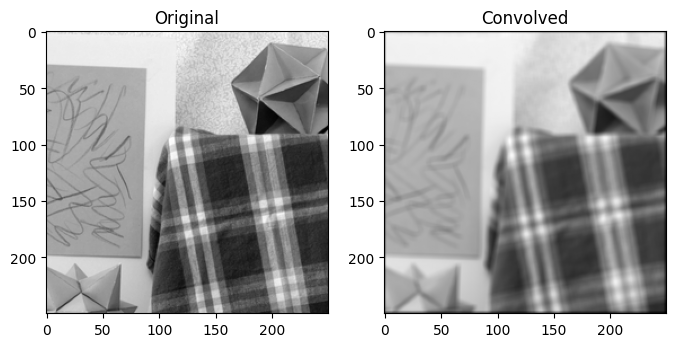

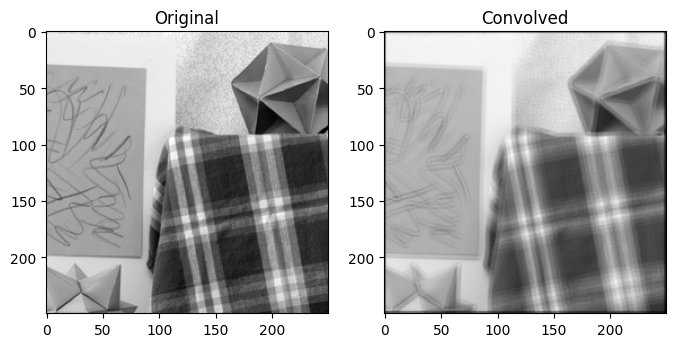

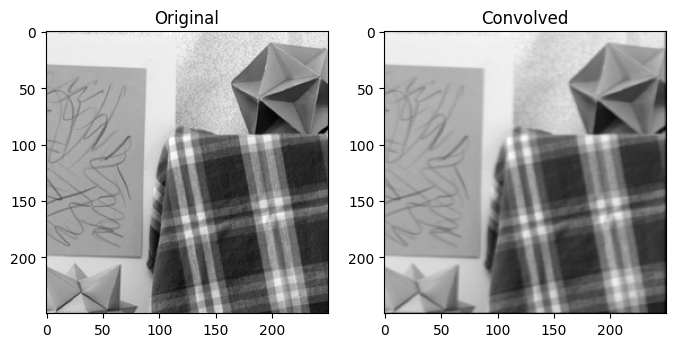

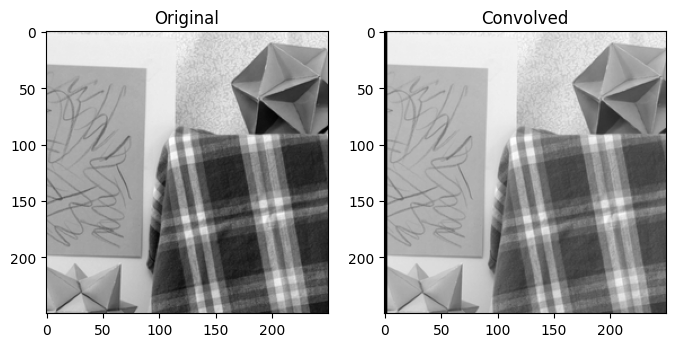

In [9]:
def test_A(imageName):
    img = cv2.imread(imageName, cv2.IMREAD_GRAYSCALE)
    convolvedImage1 = convolutionMask(img, mask1)
    convolvedImage2 = convolutionMask(img, mask2)
    convolvedImage3 = convolutionMask(img, mask3)
    convolvedImage4 = convolutionMask(img, mask4)

# Uncomments the following to test. Don't forget to try various inputs and edge cases. Feel free to add your own images.
img = 'sample_data/view6_crop.tif'
img1 = 'sample_data/perfect_checkerboard.png'
test_A(img)

## <span style="color:blue">**Section B: Corner Detector**</span>
    
In this section, you will implement the Harris corner detector as covered in class. Refer to the slides of the algorithm details.

Reference to the original paper: [A COMBINED CORNER AND EDGE DETECTOR, Harris \& Stephens, Alvey Vision Conference, 1988](https://bmva-archive.org.uk/bmvc/1988/avc-88-023.pdf)

You will write the function: \
`corners, plots = harris_corner(im, s_smooth, s_neighb, th, density_size, display)`.

<u>Inputs:</u> \
_im_: a grey-level image.\
_s_smooth_: parameter for the Gaussian used to calculate image derivatives.\
_s_neighb_: parameter for the Gaussian used to sum over a local window. \
_th_: threshold for corner detection. \
_density_size_: size of search area when performing non-maximum suppression. \
_display_: a binary parameter; if True, debug and output images are displayed.

<u>Output:</u> \
_corners_: $k\times 2$ array that consists of the $x$ and $y$ coordinates of each of the $k$  detected corners. \
_plots_: an array representing an image, with all the output plots. Use `plot2array()` (provided below) to convert matplotlib figures into an array.

## <span style="color:blue"> **B1 - Implement Harris** </span>
    
As part of the algorithm, you should implement the following:

1. Compute two kernels that calculate the approximate image derivatives: `g_dx, g_dy = deriv_gauss_xy(s_smooth)`. <br>
   Note:
   * There are many ways to compute an approximate derivative of an image, so feel free to explore.
     Your solution should take the derivative in one direction, and smooth in the orthogonal direction.
     For example, for the x derivative, the y direction should be smoothed. \
     **Thought question (not for submission)**: why is it a good idea to smooth the orthogonal direction?
   * The mask_size should be around 6$s_{smooth}$+1.
     You can check and see if smaller or larger mask sizes affect the results. You can also look at the plot of the mask.
     The values close to the border of the masks should be close to zero.
     On the other hand, the boundary region with mostly zero values should not be too wide. Think what it means if this is not the case. \
     **Thought question (not for submission)**: what is the expected sum of the elements in the kernel?
2. Using these masks compute two matrices, $I_x$ and $I_y$, with the derivatives of the image in the $x$ and in the $y$ directions, respectively: `ix, iy = grad_xy(im, s_smooth)`.
3. Compute the following three matrices: $I_x^2$, $I_y^2$,  $I_x I_y$.
4. Compute the matrices $H_{11}$, $H_{12}$, $H_{22}$, each corresponding to a different entry of the matrix $H$ for all pixels of the image. These matrices can be computed by convolving the matrices in (3) with a Gaussian defined by $s_{neighb}$.
5. Compute, for each pixel, the eigen value $\lambda_{min}$ of its $H$ matrix. \
   *or* \
   Compute $det(H)-k\cdot trace(H)^2$.  For this case you will need to add an additional paramter $k$. Give it a default value in the declaration of `harris_corner()`.
6. Threshold the result of (5), using the parameter `th`. (I.e., set to zero those pixles that are below the threshold.)
7. Non-max suppresion: for each region of size `denisty_size`, only keep the maximal value.

**Important: You are free to adjust the parameters to obtain good results. The implementation instructions above are not mandatory and serve only as guidelines. You may implement the solution as you see fit.**

Return a list of corners. If display = 1, also display:

1. The original image.
2. The derivatives of the images, $I_x$ and $I_y$.
3. The values of the corner strength before appying the threshold. (Can be in greyscale rather than color. Make sure to normalize it for display.)
4. The values of the corner strength after appying the threshold.
5. The detected corners overlayed on the original image.

In [ ]:
# You can use the following helper function to generate the second return value of harris_corner()

from PIL import Image
import io

def plot2array(fig):
    # Save the plot to a BytesIO object (in memory, as a PNG)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
    buf.seek(0)

    # Open the image using PIL and convert to a NumPy array
    pil_image = Image.open(buf)
    image_array = np.asarray(pil_image)

    # Close the buffer
    buf.close()

    return image_array

In [ ]:
# TODO: student implementation

def deriv_gauss_xy(s_smooth):
    ...


def grad_xy(im, s_smooth):
    ...


def harris_corner(im, s_smooth, s_neighb, th, density_size, display):
    ...


## <span style="color:blue"> **B2 - Apply and explore**.
In this part you will apply your Harris corner detector and explore its parameters. Feel free to add notebook cells as needed.

1. Suggest a synthetic image to test your algorithm, and present both the image and the results.
2. Test your functions on an image of your choice, exploring various parameters to achieve a 'good' result.\
    Display the results using different parameter values. Provide two images for each parameter to demonstrate its effect on the results. Use the `title()` function to clarify which pair of parameters is used.
3. Summarize the effects of each parameter on corner detection in your answer.
4. Choose a set of parameters and apply the algorithm to the image `view6_crop.tif`.
   Show the detected corners and explain one success case and one failure case of detection.
5. List 3 interesting things that you learned from this assignment.
6. What was the most non-trivial part of the assignent?

**Submit below as text**


In [ ]:
# Uncomments the following (and change parameters) to test. Don't forget to try various inputs and edge cases.

#im = cv2.imread('perfect_checkerboard.png', cv2.IMREAD_GRAYSCALE)
#corners = harris_corner(im, s_smooth=1.0, s_neighb=2.0, th=0.01, density_size=10, display=1)

#im2 = cv2.imread('view6_crop.tif', cv2.IMREAD_GRAYSCALE)
#corners_view6, overlay_view6 = harris_corner(im2, s_smooth=0.3, s_neighb=1.0, th=100.0, density_size=9, display=1)

# Answer variables for the final display cell:
# param_effect_summary = "..."
# three_insights = ["...", "...", "..."]
# non_trivial_part = "..."

## Final Variables to Display

To keep submission simple, define these variables in your notebook code:

- `mask1`, `mask2`, `mask3`, `mask4`
- `corners_view6`
- `overlay_view6` (image array with displayed/marked corners)
- `param_effect_summary` (short text)
- `three_insights` (list of 3 strings)
- `non_trivial_part` (short text)

The final display cell reads these variables directly.


## Final Results Display

This section displays all final outputs directly in the notebook for quick manual review.


In [ ]:
def show_array(name, value):
    if value is None:
        print(f"{name}: MISSING")
        return
    arr = np.asarray(value)
    print(f"{name}: shape={arr.shape}, dtype={arr.dtype}")
    print(arr)


def show_text(name, value):
    if value is None:
        print(f"{name}: MISSING")
    else:
        print(f"{name}: {value}")


print("=" * 60)
print("Section A - Masks")
print("=" * 60)
show_array("mask1", globals().get("mask1", None))
show_array("mask2", globals().get("mask2", None))
show_array("mask3", globals().get("mask3", None))
show_array("mask4", globals().get("mask4", None))

print("\n" + "=" * 60)
print("Section B - Corner Outputs")
print("=" * 60)
show_array("corners_view6", globals().get("corners_view6", None))

overlay = globals().get("overlay_view6", None)
if overlay is not None:
    arr = np.asarray(overlay)
    plt.figure(figsize=(5, 5))
    if arr.ndim == 2:
        plt.imshow(arr, cmap="gray")
    else:
        plt.imshow(arr)
    plt.title("overlay_view6")
    plt.axis("off")
    plt.show()
else:
    print("overlay_view6: MISSING")

print("\n" + "=" * 60)
print("Section B2 - Text Answers")
print("=" * 60)
show_text("param_effect_summary", globals().get("param_effect_summary", None))
show_text("three_insights", globals().get("three_insights", None))
show_text("non_trivial_part", globals().get("non_trivial_part", None))
